# demo_agents026 – Autonomous Incident Diagnosis & Resolution Agent

This is the polished demo notebook for the AGENTS026 prototype. It is designed for walkthrough/demo usage rather than development.

Recommended flow during the demo:
1. Briefly explain the problem and generated telemetry.
2. Show anomaly detection and incident candidates.
3. Show similarity search over historical incidents and runbooks.
4. Run RCA + remediation for one incident.
5. Show final report and KB growth.

This notebook also captures step-level timings and basic GPU usage snapshots for technical credibility.


## Setup – Imports, Paths, and Metrics Helpers

Load all previously generated artifacts and define helper functions for timing and GPU snapshots.


In [1]:
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Optional, Any
import os
import json
import time
import subprocess
from contextlib import contextmanager

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

root = Path.cwd() / 'agents026'
data_dir = root / 'data'
incidents_dir = data_dir / 'incidents'
exec_dir = data_dir / 'execution'
vector_dir = data_dir / 'vectorstore'
reports_dir = data_dir / 'reports'
kb_dir = data_dir / 'kb'

metrics_log = []

def gpu_snapshot() -> Dict[str, str]:
    cmds = [
        'rocm-smi --showuse --showmemuse --showtemp --csv',
        'amd-smi monitor --csv',
    ]
    for cmd in cmds:
        try:
            out = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, text=True, timeout=20)
            return {'command': cmd, 'output': out[:4000]}
        except Exception:
            continue
    return {'command': 'unavailable', 'output': 'No GPU monitoring command available in PATH'}

@contextmanager
def timed_step(step_name: str):
    t0 = time.perf_counter()
    gpu_before = gpu_snapshot()
    yield
    elapsed = time.perf_counter() - t0
    gpu_after = gpu_snapshot()
    metrics_log.append({
        'step': step_name,
        'elapsed_sec': round(elapsed, 4),
        'gpu_before_cmd': gpu_before['command'],
        'gpu_before': gpu_before['output'],
        'gpu_after_cmd': gpu_after['command'],
        'gpu_after': gpu_after['output'],
    })

print('Setup complete')


Setup complete


## Load Artifacts

Read the outputs created by earlier notebooks. This demo notebook assumes the hour-by-hour notebooks have already been executed successfully.


In [2]:
with open(incidents_dir / 'incident_candidates.json', 'r', encoding='utf-8') as f:
    incident_candidates_raw = json.load(f)

with open(incidents_dir / 'rca_results.json', 'r', encoding='utf-8') as f:
    rca_results_raw = json.load(f)

metrics_df = pd.read_csv(data_dir / 'metrics.csv', parse_dates=['timestamp'])
logs_df = pd.read_csv(data_dir / 'app_logs.csv', parse_dates=['timestamp'])
changes_df = pd.read_csv(data_dir / 'change_events.csv', parse_dates=['timestamp'])
incident_table_df = pd.DataFrame([{
    'incident_id': x['incident_id'],
    'service': ','.join(x['services']),
    'anomaly_type': x['anomaly_type'],
    'start_time': x['start_time'],
    'end_time': x['end_time'],
    'cpu_max': x.get('metric_summary', {}).get('cpu_max'),
    'latency_p95_max': x.get('metric_summary', {}).get('latency_p95_max'),
    'error_rate_max': x.get('metric_summary', {}).get('error_rate_max'),
} for x in incident_candidates_raw])

workflow_summary_df = pd.read_parquet(exec_dir / 'workflow_summary.parquet') if (exec_dir / 'workflow_summary.parquet').exists() else pd.DataFrame()
report_summary_df = pd.read_parquet(reports_dir / 'report_summary.parquet') if (reports_dir / 'report_summary.parquet').exists() else pd.DataFrame()
kb_df = pd.read_parquet(kb_dir / 'resolved_incidents_kb.parquet') if (kb_dir / 'resolved_incidents_kb.parquet').exists() else pd.DataFrame()

len(incident_candidates_raw), len(rca_results_raw), len(kb_df)


(4, 2, 2)

## Section 1 – Problem & Data Overview

This section frames the AIOps problem and summarizes the generated telemetry used in the demo.


In [3]:
display(Markdown('''
### Why this matters
Modern microservice environments generate high-volume metrics, logs, deployment events, and infra signals.
During an outage, SREs need to: detect anomalies, correlate signals, retrieve similar incidents, infer likely root cause, propose actions, and capture post-incident knowledge.

### Demo data
- Services: checkout-api, catalog-api, payments-service, auth-service
- Telemetry: CPU, RPS, p95 latency, error rate
- Context: application logs, K8s-style events, deploy/config changes
- Workflow: anomaly detection → incident construction → retrieval → RCA → remediation → reporting → KB update
'''))

overview = {
    'metrics_rows': len(metrics_df),
    'logs_rows': len(logs_df),
    'changes_rows': len(changes_df),
    'incident_candidates': len(incident_candidates_raw),
    'resolved_kb_rows': len(kb_df),
}
pd.DataFrame([overview])



### Why this matters
Modern microservice environments generate high-volume metrics, logs, deployment events, and infra signals.
During an outage, SREs need to: detect anomalies, correlate signals, retrieve similar incidents, infer likely root cause, propose actions, and capture post-incident knowledge.

### Demo data
- Services: checkout-api, catalog-api, payments-service, auth-service
- Telemetry: CPU, RPS, p95 latency, error rate
- Context: application logs, K8s-style events, deploy/config changes
- Workflow: anomaly detection → incident construction → retrieval → RCA → remediation → reporting → KB update


,metrics_rows,logs_rows,changes_rows,incident_candidates,resolved_kb_rows
0,964,974,16,4,2


In [4]:
with timed_step('problem_data_overview'):
    service_counts = metrics_df.groupby('service').size().reset_index(name='metric_points')
display(service_counts)


,service,metric_points
0,auth-service,241
1,catalog-api,241
2,checkout-api,241
3,payments-service,241


## Section 2 – Anomaly Detection & Incident List

Show the detected incidents and one representative metric chart.


In [5]:
with timed_step('incident_list_view'):
    display(incident_table_df.sort_values(['service', 'start_time']).head(20))


,incident_id,service,anomaly_type,start_time,end_time,cpu_max,latency_p95_max,error_rate_max
0,inc-001,catalog-api,error_rate,2026-06-10 12:19:00,2026-06-10 12:19:00,26.111974,161.081061,0.003206
1,inc-002,catalog-api,error_rate,2026-06-10 12:29:00,2026-06-10 12:29:00,19.477817,158.860977,0.002824
2,inc-003,catalog-api,error_rate,2026-06-10 12:36:00,2026-06-10 12:42:00,24.494021,160.371294,0.004188
3,inc-004,catalog-api,error_rate,2026-06-10 12:58:00,2026-06-10 12:58:00,22.828380,140.693808,0.003110


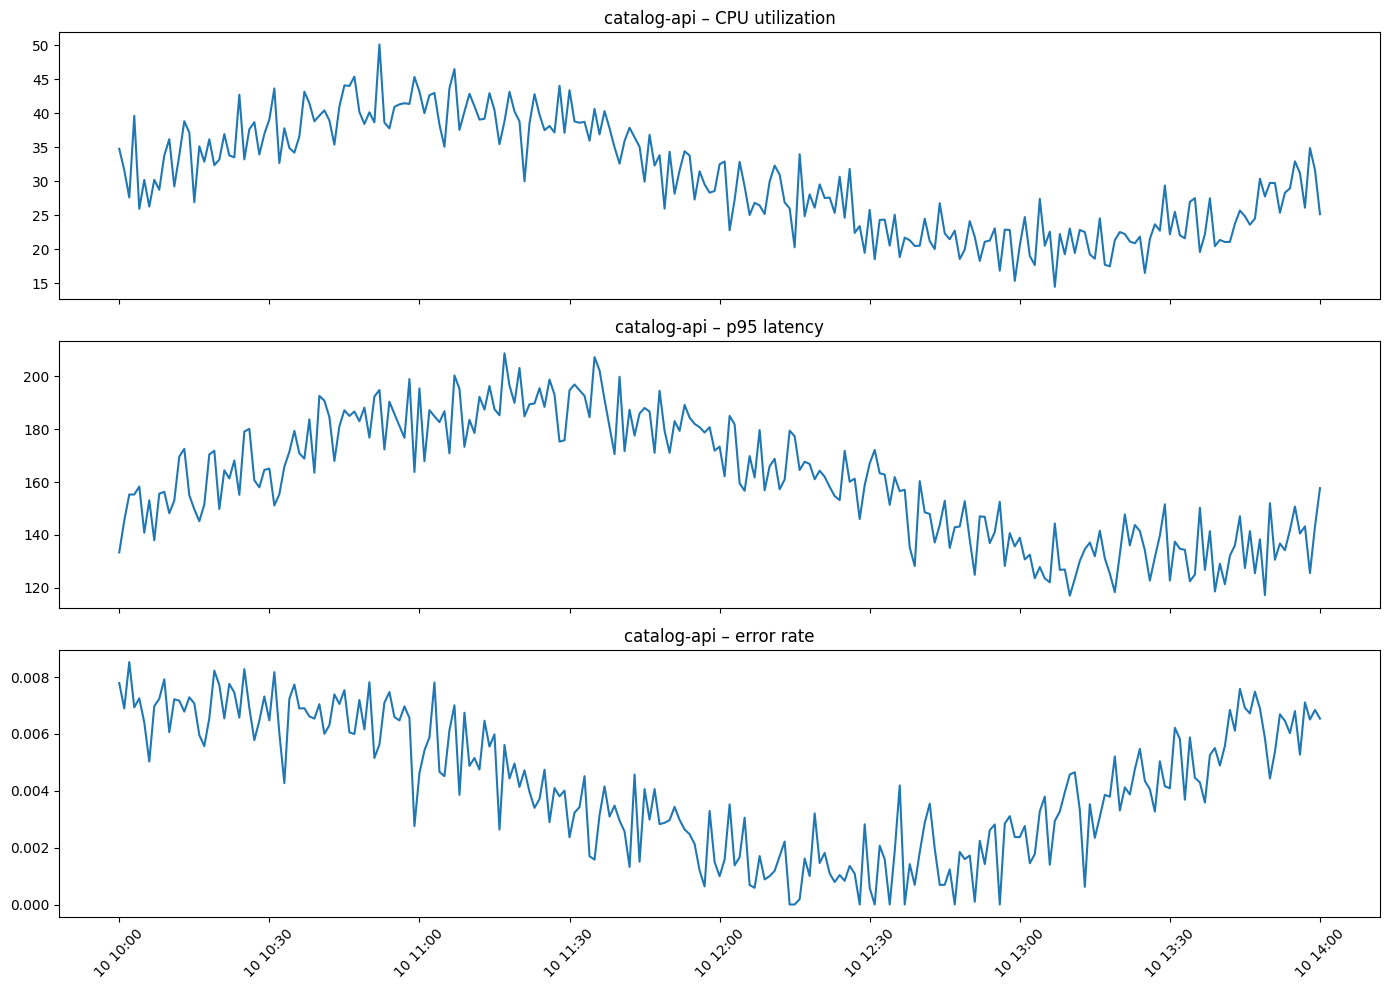

In [6]:
chosen_service = incident_table_df['service'].iloc[0] if not incident_table_df.empty else 'checkout-api'
svc_df = metrics_df[metrics_df['service'] == chosen_service].sort_values('timestamp').copy()

with timed_step('anomaly_plot'):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(svc_df['timestamp'], svc_df['cpu_utilization'])
    axes[0].set_title(f'{chosen_service} – CPU utilization')
    axes[1].plot(svc_df['timestamp'], svc_df['latency_p95_ms'])
    axes[1].set_title(f'{chosen_service} – p95 latency')
    axes[2].plot(svc_df['timestamp'], svc_df['error_rate'])
    axes[2].set_title(f'{chosen_service} – error rate')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Section 3 – Similarity Search Example

Show how the system retrieves relevant historical incidents/runbooks/KB entries for a chosen incident.


In [7]:
import faiss
from sentence_transformers import SentenceTransformer
import torch

corpus_df = pd.read_parquet(vector_dir / 'incident_runbook_metadata.parquet')
faiss_index = faiss.read_index(str(vector_dir / 'incident_runbook.index'))
embed_device = 'cuda' if torch.cuda.is_available() else 'cpu'
embed_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=embed_device)

def embed_texts(texts, batch_size=16):
    return embed_model.encode(texts, batch_size=batch_size, convert_to_numpy=True, normalize_embeddings=True).astype('float32')

def search_similar_text(query_text: str, top_k: int = 5) -> pd.DataFrame:
    q = embed_texts([query_text], batch_size=1)
    scores, ids = faiss_index.search(q, top_k)
    rows = []
    for score, idx in zip(scores[0], ids[0]):
        if idx == -1:
            continue
        row = corpus_df.iloc[int(idx)].to_dict()
        row['score'] = float(score)
        rows.append(row)
    return pd.DataFrame(rows)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [8]:
chosen_incident = incident_candidates_raw[0] if incident_candidates_raw else None
if chosen_incident:
    query_text = f"service={','.join(chosen_incident['services'])}; anomaly={chosen_incident['anomaly_type']}; logs={' | '.join(chosen_incident.get('log_samples', [])[:3])}"
    with timed_step('similarity_search'):
        sim_df = search_similar_text(query_text, top_k=8)
    display(sim_df[['doc_id', 'doc_type', 'service', 'title', 'score']])
else:
    print('No incident candidates available')


,doc_id,doc_type,service,title,score
0,inc-001,incident_candidate,catalog-api,Incident candidate inc-001,0.875518
1,inc-002,incident_candidate,catalog-api,Incident candidate inc-002,0.864359
2,inc-003,incident_candidate,catalog-api,Incident candidate inc-003,0.855423
3,inc-004,incident_candidate,catalog-api,Incident candidate inc-004,0.854565
4,kb-inc-002,resolved_incident_kb,catalog-api,Resolved incident inc-002,0.625914
5,kb-inc-001,resolved_incident_kb,catalog-api,Resolved incident inc-001,0.617283
6,hist-003,historical_incident,auth-service,Auth failures after config change,0.366090
7,hist-002,historical_incident,payments-service,Payment error spike due to DB pool exhaustion,0.332286


## Section 4 – RCA + Remediation Run

Show the output of RCA and the resulting remediation/execution workflow for one chosen incident.


In [9]:
workflow_files = sorted(exec_dir.glob('*_workflow.json'))
workflow_bundles = []
for fp in workflow_files:
    with open(fp, 'r', encoding='utf-8') as f:
        workflow_bundles.append(json.load(f))

workflow_map = {x['incident_id']: x for x in workflow_bundles}
chosen_incident_id = chosen_incident['incident_id'] if chosen_incident else None

with timed_step('rca_remediation_display'):
    if chosen_incident_id in workflow_map:
        bundle = workflow_map[chosen_incident_id]
        display(Markdown(f"### RCA for {chosen_incident_id}\n\n**Root cause hypothesis:** {bundle['rca_result']['root_cause_hypothesis']}\n\n**Probable trigger:** {bundle['rca_result'].get('probable_trigger')}"))
        display(pd.DataFrame(bundle['action_plan']['actions'])[['action_type', 'target', 'requires_approval', 'status', 'expected_impact']])
        display(pd.DataFrame(bundle['execution_result']['executed_actions']) if bundle['execution_result']['executed_actions'] else pd.DataFrame(columns=['action_type','target','status']))
        display(pd.DataFrame(bundle['execution_result']['skipped_actions']) if bundle['execution_result']['skipped_actions'] else pd.DataFrame(columns=['action_type','target','status']))
    else:
        print('No workflow bundle found for chosen incident')


### RCA for inc-001

**Root cause hypothesis:** The error rate increase in catalog-api is likely due to a recent deployment (v2.1.8) and feature flag activation (v2.2.2) around 12:13-12:16. These changes may have introduced inefficiencies or errors in request handling, leading to higher error rates.

**Probable trigger:** deploy

,action_type,target,requires_approval,status,expected_impact
0,scale_service,catalog-api,False,executed,"Reduced load on the service, potential improve..."
1,disable_feature_flag,catalog-api,True,skipped,"Potential rollback of feature changes, which m..."
2,rollback_deploy,catalog-api,True,skipped,"Restores the service to a known good state, po..."
3,clear_cache,catalog-api,False,executed,Potential temporary performance hit but may re...


,action_id,action_type,target,description,parameters,requires_approval,status,expected_impact,rationale
0,action-001,scale_service,catalog-api,Scale down the catalog-api service to reduce l...,{'replicas': 1},False,executed,"Reduced load on the service, potential improve...",Scaling down the service can help mitigate the...
1,action-004,clear_cache,catalog-api,Clear the cache for the catalog-api service to...,{},False,executed,Potential temporary performance hit but may re...,Clearing the cache can eliminate issues caused...


,action_id,action_type,target,description,parameters,requires_approval,status,expected_impact,rationale
0,action-002,disable_feature_flag,catalog-api,Disable the recently activated feature flag (v...,{'feature_flag': 'v2.2.2'},True,skipped,"Potential rollback of feature changes, which m...",Disabling the feature flag could revert the se...
1,action-003,rollback_deploy,catalog-api,Rollback the recent deployment (v2.1.8) to a p...,{'version': 'v2.1.7'},True,skipped,"Restores the service to a known good state, po...",Rolling back the deployment may eliminate the ...


## Section 5 – Final Report & KB Update

Show the generated markdown report and how the knowledge base expands as incidents are finalized.


In [10]:
report_path = reports_dir / f'{chosen_incident_id}_report.md' if chosen_incident_id else None
with timed_step('final_report_display'):
    if report_path and report_path.exists():
        display(Markdown(report_path.read_text(encoding='utf-8')))
    else:
        print('No final report found for chosen incident')


## Post-Incident Report for Incident inc-001

### Summary
The incident involved a spike in error rates for the catalog-api service, which was traced back to recent deployments and feature flag changes. The root cause was identified as the deployment of version v2.1.8 and the activation of feature flag v2.2.2, which introduced inefficiencies in request handling. The actions taken included scaling down the service and clearing the cache, which helped mitigate the issue.

### Timeline
- **2026-06-10T12:13:00**: Feature flag (v2.2.2) applied to catalog-api.
- **2026-06-10T12:16:00**: Deployment (v2.1.8) applied to catalog-api.
- **2026-06-10T12:19:00**: Anomaly detected: error rate increased to 0.0032.
- **2026-06-10T12:20:00**: Action executed: scale_service (replicas=1) on catalog-api.
- **2026-06-10T12:24:00**: Action executed: clear_cache on catalog-api.

### Root Cause Analysis (RCA)
- **Root Cause Hypothesis**: The error rate increase is likely due to the recent deployment (v2.1.8) and feature flag activation (v2.2.2) around 12:13-12:16. These changes may have introduced inefficiencies or errors in request handling, leading to higher error rates.
- **Impacted Components**: catalog-api
- **Probable Trigger**: deploy
- **Evidence**: 
  - Similar incidents (inc-003, inc-002) involved deployment changes and feature flags.
  - Recent changes show a deploy at 12:16 and feature flag at 12:13.
  - Error rates spiked after these changes.
- **Confidence**: 95%

### Actions Taken
- **Scale Service**: Reduced replicas of catalog-api to 1 to mitigate load and error propagation.
- **Clear Cache**: Cleared the cache for catalog-api to remove corrupted or outdated data.

### Follow-up
- **Review Action Approval Process**: Investigate why disable_feature_flag and rollback_deploy actions were skipped due to approval requirements.
- **Monitor Service**: Continue monitoring catalog-api for any residual issues or recurrence of error rates.
- **Document Changes**: Ensure all deployments and feature flag changes are well-documented and reviewed before implementation to prevent similar incidents.


,incident_id,services,anomaly_type,root_cause_hypothesis,confidence
0,inc-001,catalog-api,error_rate,The error rate increase in catalog-api is like...,0.95
1,inc-002,catalog-api,error_rate,The error rate increase in catalog-api is like...,0.85


,stage,rows
0,resolved_incidents_kb,2
1,workflow_summary_rows,2
2,report_summary_rows,2


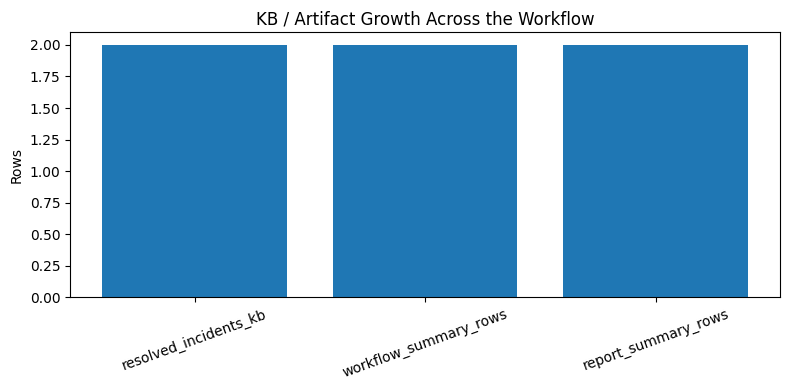

In [11]:
with timed_step('kb_growth_display'):
    if not kb_df.empty:
        display(kb_df[['incident_id', 'services', 'anomaly_type', 'root_cause_hypothesis', 'confidence']])
        growth_rows = [
            {'stage': 'resolved_incidents_kb', 'rows': len(kb_df)},
            {'stage': 'workflow_summary_rows', 'rows': len(workflow_summary_df)},
            {'stage': 'report_summary_rows', 'rows': len(report_summary_df)},
        ]
        growth_df = pd.DataFrame(growth_rows)
        display(growth_df)
        plt.figure(figsize=(8, 4))
        plt.bar(growth_df['stage'], growth_df['rows'])
        plt.title('KB / Artifact Growth Across the Workflow')
        plt.ylabel('Rows')
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()
    else:
        print('KB is empty')


## Section 6 – Timing & GPU Metrics

Summarize end-to-end latency and per-step timings captured during the demo notebook execution.


In [12]:
metrics_df_demo = pd.DataFrame(metrics_log)
metrics_df_demo


,step,elapsed_sec,gpu_before_cmd,gpu_before,gpu_after_cmd,gpu_after
0,problem_data_overview,0.1239,rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe...",rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe..."
1,incident_list_view,0.1384,rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe...",rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe..."
2,anomaly_plot,0.5277,rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe...",rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe..."
3,similarity_search,3.8659,rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe...",rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe..."
4,rca_remediation_display,0.1710,rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe...",rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe..."
5,final_report_display,0.1247,rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe...",rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe..."
6,kb_growth_display,0.2631,rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe...",rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe..."


,end_to_end_latency_sec
0,5.2147


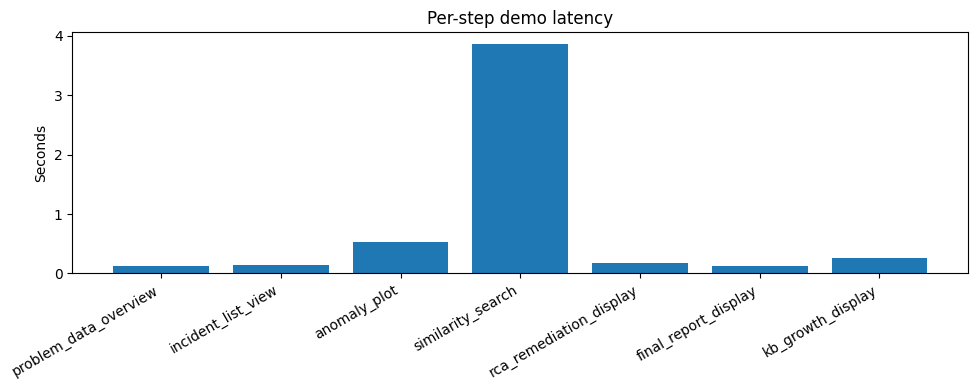

In [13]:
if not metrics_df_demo.empty:
    total_latency = metrics_df_demo['elapsed_sec'].sum()
    display(pd.DataFrame([{'end_to_end_latency_sec': round(total_latency, 4)}]))
    plt.figure(figsize=(10, 4))
    plt.bar(metrics_df_demo['step'], metrics_df_demo['elapsed_sec'])
    plt.title('Per-step demo latency')
    plt.ylabel('Seconds')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No timing data captured yet')


In [14]:
if not metrics_df_demo.empty:
    latest_gpu = metrics_df_demo.iloc[-1]['gpu_after']
    print('Latest GPU snapshot:')
    print(latest_gpu)
else:
    print('No GPU snapshots captured yet')


Latest GPU snapshot:
device,Temperature (Sensor junction) (C),Temperature (Sensor memory) (C),GPU use (%),GPU Memory Allocated (VRAM%),GPU Memory Read/Write Activity (%),Memory Activity
card0,52.0,45.0,0,92,0,N/A




## Section 7 – Demo Closing Notes

Use these bullets as a verbal wrap-up during the hackathon demo.


In [15]:
display(Markdown('''
### Key takeaways
- The notebook shows an end-to-end AIOps loop: detection, retrieval, RCA, remediation, reporting, and KB growth.
- The solution uses AMD GPU-backed model serving / embeddings for semantic reasoning and retrieval.
- The workflow is modular: each stage can later be productionized behind services, schedulers, and real infrastructure integrations.
- The demo keeps execution safe by using policy-aware mock actions while preserving realistic orchestration and auditability.
'''))



### Key takeaways
- The notebook shows an end-to-end AIOps loop: detection, retrieval, RCA, remediation, reporting, and KB growth.
- The solution uses AMD GPU-backed model serving / embeddings for semantic reasoning and retrieval.
- The workflow is modular: each stage can later be productionized behind services, schedulers, and real infrastructure integrations.
- The demo keeps execution safe by using policy-aware mock actions while preserving realistic orchestration and auditability.
